# Description
```
Problem   : Classification : Multi Label
Type      : Deep learning
Algorithm : Neural network : Functional API
Network   : CNN 
Action    : Relu | Softmax
Loss      : categorical_crossentropy
Train     : Supervised
Input     : Feature | Two labels
Output    : Category | Color
Dataset   : Unstructured : Clothes
```

# General

Import

In [ ]:
import glob, os
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from keras.optimizers.schedules import ExponentialDecay
from keras import optimizers
from keras import models, layers
from keras.models import load_model

Variable

In [ ]:
root_dir = '/Volumes/data/documents/ai_document'
data_dir = '/Volumes/data/develop/ai/'

# Dataset

### Read

In [ ]:
dataset = []
labels_category = []
labels_color = []
for address in glob.glob(f"{data_dir}/dataset/clothes/dataset/**/*.*", recursive=True):
    #---Direction
    path = os.path.dirname(address)
    directory = path.split('/')[-1].split('.')[0]
    #---Data
    img = cv.imread(address)
    dataset.append(img)
    #---Label
    (label_color, label_category) = directory.split("_")
    labels_color.append(label_color)
    labels_category.append(label_category)

### Display

Data

In [ ]:
print("Len: {}".format(len(dataset)))
plt.imshow(dataset[0])
plt.show()

Color

In [ ]:
print("Len: {}".format(len(labels_color)))
print(labels_color[0])

Category

In [ ]:
print("Len: {}".format(len(labels_category)))
print(labels_category[0])

# Label Encoding

Color

In [ ]:
output_color = ['black', 'blue', 'red']
colorLB = LabelBinarizer()
labels_color = colorLB.fit_transform(labels_color)
print("Shape: {}".format(labels_color.shape))
print(labels_color[0])

Category

In [ ]:
output_category = ['jeans', 'shoes', 'dress', 'shirt']
categoryLB = LabelBinarizer()
labels_category = categoryLB.fit_transform(labels_category)
print("Shape: {}".format(labels_category.shape))
print(labels_category[0])

# Preprocessing

In [ ]:
data = []
for img in dataset:
    #---Resize
    img = cv.resize(img, (96, 96))
    #---RGB
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    #---Add
    data.append(img)
#---Convert
data = np.array(data)

print("Shape: {}".format(data.shape))

# Normalization

In [ ]:
data = data/255.0

# Separate tarin and test

In [ ]:
split = train_test_split(
    data, 
    labels_color,
    labels_category,
    test_size=0.15, 
    random_state=42
)
(x_train, x_test, y_train_co, y_test_co, y_train_ct, y_test_ct) = split

print(x_train.shape)
print(x_test.shape)
print(y_train_co.shape)
print(y_test_co.shape)
print(y_train_ct.shape)
print(y_test_ct.shape)

# Model

### Configuration

Optimizers

In [ ]:
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=255,
    decay_rate=0.001,
    staircase=False
)

opt_sgd = optimizers.SGD(learning_rate=lr_schedule)
opt_adam = optimizers.Adam(learning_rate=lr_schedule)

Mertic

In [ ]:
metrics={
    "color": "accuracy",
    "category": "accuracy"
}

Loss

In [ ]:
losses = {
    "color" : "categorical_crossentropy",
    "category" : "categorical_crossentropy"
}

Weight

In [ ]:
weights = {
    "color" : 1.0,
    "category" : 1.0
}

Output count

In [ ]:
color_classes = len(colorLB.classes_)
category_classes = len(categoryLB.classes_)
print("color_classes: {}".format(color_classes))
print("category_classes: {}".format(category_classes))

### Layers

Input

In [ ]:
input_layer = layers.Input(shape=(96, 96, 3))

Color

In [ ]:
x = layers.Conv2D(16, (3, 3),activation="relu", padding="same") (input_layer)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D((3, 3))(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(32, (3, 3),activation="relu", padding="same") (x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D((2, 2 ))(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(32, (3, 3),activation="relu", padding="same") (x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D((2, 2 ))(x)
x = layers.Dropout(0.25)(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(color_classes)(x)

net_color = layers.Activation(activation="softmax", name="color")(x)

Category

In [ ]:
y = layers.Conv2D(32, (3, 3),activation="relu", padding="same")(input_layer)
y = layers.BatchNormalization()(y)
y = layers.MaxPool2D((3, 3))(y)
y = layers.Dropout(0.25)(y)

y = layers.Conv2D(64, (3, 3),activation="relu", padding="same") (y)
y = layers.BatchNormalization()(y)
y = layers.Conv2D(64, (3, 3),activation="relu", padding="same") (y)
y = layers.BatchNormalization()(y)
y = layers.MaxPool2D((2, 2 ))(y)
y = layers.Dropout(0.25)(y)

y = layers.Conv2D(128, (3, 3),activation="relu", padding="same")(y)
y = layers.BatchNormalization()(y)
y = layers.Conv2D(128, (3, 3),activation="relu", padding="same")(y)
y = layers.BatchNormalization()(y)
y = layers.MaxPool2D((2, 2 ))(y)
y = layers.Dropout(0.25)(y)

y = layers.Flatten()(y)
y = layers.Dense(256, activation="relu")(y)
y = layers.BatchNormalization()(y)
y = layers.Dropout(0.5)(y)
y = layers.Dense(category_classes)(y)

net_category = layers.Activation(activation="softmax", name="category")(y)

### Generate

In [ ]:
mdl = models.Model(
    inputs=input_layer, 
    outputs = [net_color, net_category], 
    name="Fashion"
)

### Compile

In [ ]:
mdl.compile(
    optimizer=opt_adam, 
    loss=losses,
    loss_weights = weights,
    metrics=metrics
)

# Train

In [ ]:
EPOCHS = 20
BATCH_SIZE = 32

H = mdl.fit(
    x = x_train, 
    y = {"color":y_train_co, "category":y_train_ct},
    validation_data=(x_test, {"color":y_test_co, "category":y_test_ct}),
    epochs=EPOCHS
)

### Save

In [ ]:
mdl.save(f"{data_dir}/model/classification_multi_label.h5")

# Evaluation

### Color 

Loss and Accuracy

In [ ]:
#loss, accuracy = mdl.evaluate(x_test, y_test_ct)
#print("Loss: {:.2f} | Accuracy: {:.2f}".format(loss, accuracy))

Accuracy

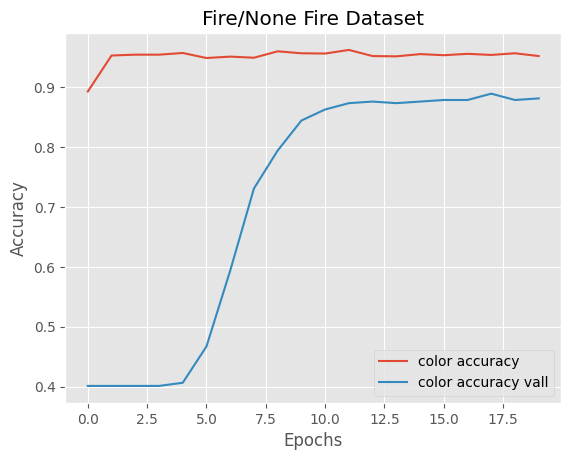

In [36]:
plt.plot(H.history['color_accuracy'], label='color accuracy')
plt.plot(H.history['val_color_accuracy'], label='color accuracy vall')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Fire/None Fire Dataset')
plt.style.use('ggplot')
plt.show()

Loss

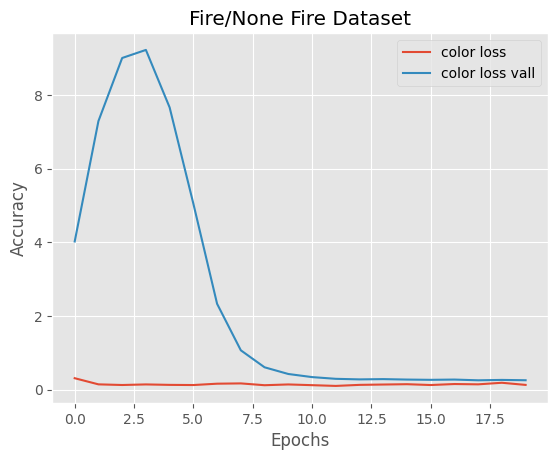

In [37]:
plt.plot(H.history['color_loss'], label='color loss')
plt.plot(H.history['val_color_loss'], label='color loss vall')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Fire/None Fire Dataset')
plt.style.use('ggplot')
plt.show()

### Color

Loss and Accuracy

In [ ]:
#loss, accuracy = mdl.evaluate(x_test, y_test)
#print("Loss: {:.2f} | Accuracy: {:.2f}".format(loss, accuracy))

accuracy

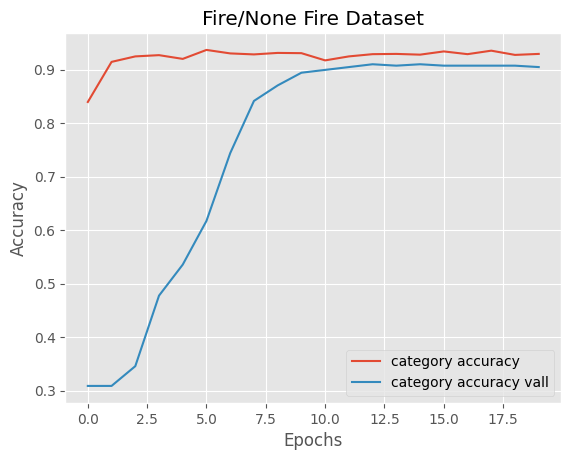

In [38]:
plt.plot(H.history['category_accuracy'], label='category accuracy')
plt.plot(H.history['val_category_accuracy'], label='category accuracy vall')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Fire/None Fire Dataset')
plt.style.use('ggplot')
plt.show()

Loss

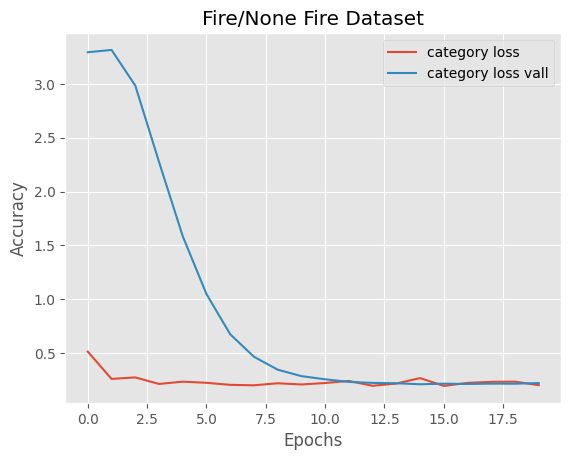

In [39]:
plt.plot(H.history['category_loss'], label='category loss')
plt.plot(H.history['val_category_loss'], label='category loss vall')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Fire/None Fire Dataset')
plt.style.use('ggplot')
plt.show()

# Test

Shape: (1440, 960, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Color: red
Category: dress


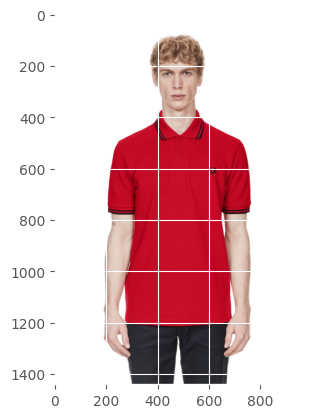

Shape: (533, 320, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Color: black
Category: shoes


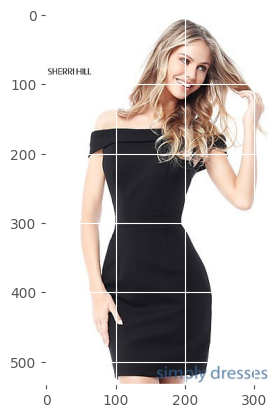

Shape: (618, 412, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Color: blue
Category: shoes


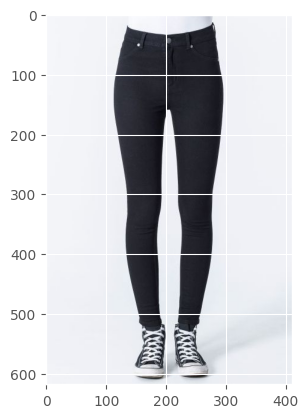

Shape: (736, 736, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Color: red
Category: shoes


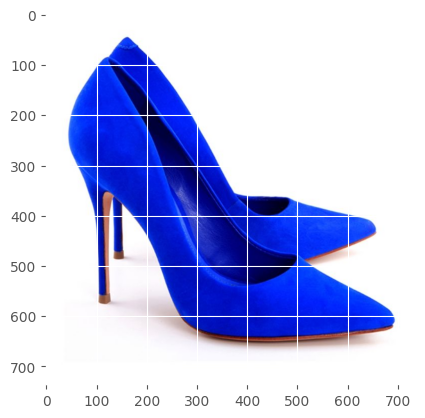

Shape: (1000, 1000, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Color: black
Category: dress


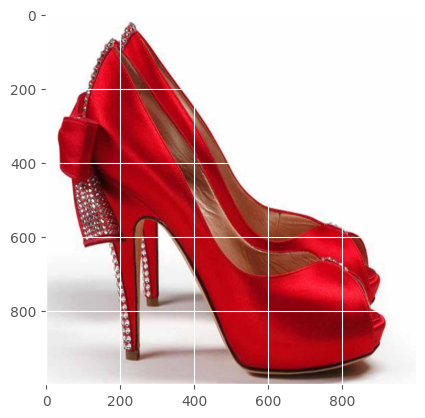

In [40]:
mdl = load_model(f"{data_dir}/model/classification_multi_label.h5")
for address in glob.glob(f"{data_dir}/dataset/clothes/predict/*.*"):
    #---Path
    path = os.path.dirname(address)
    name = os.path.splitext(os.path.basename(address))[0]
    extension = os.path.splitext(os.path.basename(address))[1] 
    #---Read image
    img = cv.imread(address)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    #---Shape
    print("Shape: {}".format(img.shape))
    #---Preprocessing
    img = cv.resize(img, (96, 96))
    img = img/255.0
    img = np.array([img])
    #---Predict 
    (category, color) = mdl.predict(img)
    pred_color_max = np.argmax(color)
    out_color = output_color[pred_color_max]
    pred_category_max = np.argmax(category)
    out_category = output_category[pred_category_max]
    print("Color: {}".format(out_color))
    print("Category: {}".format(out_category))
    #---Display
    img = cv.imread(address)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.show()